# Análisis de Robustez — CNN Clasificador QR

Este notebook evalúa si el modelo aprendió **patrones visuales reales** del QR
o **artifacts del generador** (metadatos PNG, compresión, etc.).

Metodología:
1. Evaluar el modelo en test **tal cual** (baseline).
2. Evaluar en test con imágenes **re-encodeadas** (se destruyen metadatos PNG).
3. Evaluar con **degradaciones visuales** (ruido, blur, JPEG, rotación, recorte).
4. Comparar deltas y concluir.

## 0. Setup

In [2]:
from pathlib import Path
from io import BytesIO
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from cnn_model import QRCNN, SEED

#  Configuración
IMG_SIZE = 128
BATCH    = 128
OUT_DIR  = Path("outputs")

In [3]:
#  Dispositivo
device = (
    torch.device("cuda")  if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 1. Cargar modelo y datos de test

In [4]:
model = QRCNN(dropout=0.4).to(device)
model.load_state_dict(torch.load(OUT_DIR / "best_model.pt", map_location=device))
model.eval()
print(f"Modelo cargado desde {OUT_DIR / 'best_model.pt'}")
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Modelo cargado desde outputs/best_model.pt
Parámetros: 3,142,242


In [13]:
test_df     = pd.read_csv("data_procesada/test.csv")
test_paths  = test_df["filepath"].tolist()
test_labels = test_df["label"].tolist()

print(f"Test set: {len(test_df):,} imágenes")
print(test_df["label_name"].value_counts().to_string())

Test set: 30,000 imágenes
label_name
normal     15000
malware    15000


## 2. Dataset flexible y funciones de evaluación

Definimos un `Dataset` que acepta una función `loader` opcional.
Esto nos permite cambiar la forma de cargar/transformar la imagen
sin tocar el modelo.

In [21]:
class QRDatasetFlex(Dataset):
    """Dataset que acepta un loader personalizado.
    loader(filepath) -> PIL.Image ya en escala de grises.
    """
    def __init__(self, filepaths, labels, loader=None):
        self.filepaths = filepaths
        self.labels    = labels
        self.loader    = loader or self._default_loader

    @staticmethod
    def _default_loader(fp):
        return Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img   = self.loader(self.filepaths[idx])
        img_t = torch.tensor(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_t, label


def make_loader(filepaths, labels, loader_fn=None):
    ds = QRDatasetFlex(filepaths, labels, loader_fn)
    return DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)


@torch.no_grad()
def run_eval(data_loader, desc="Evaluando"):
    all_preds, all_probs, all_labels = [], [], []
    model.eval()
    for imgs, labels in tqdm(data_loader, desc=desc, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def report(name, true, preds, probs):
    acc = accuracy_score(true, preds)
    auc = roc_auc_score(true, probs)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.6f}")
    print(f"  AUC      : {auc:.6f}")
    print(f"{'─'*50}")
    return {"name": name, "accuracy": acc, "auc": auc}

## 3. Baseline (imágenes originales)

Punto de referencia: el mismo pipeline con el que se entrenó el modelo.

In [22]:
loader_original = make_loader(test_paths, test_labels)
true, preds_orig, probs_orig = run_eval(loader_original, "Baseline")
results = [report("Baseline (original)", true, preds_orig, probs_orig)]


──────────────────────────────────────────────────
  Baseline (original)
  Accuracy : 0.999867
  AUC      : 1.000000
──────────────────────────────────────────────────


## 4. Experimento 1 — Re-encodeo PNG

Al re-encodear la imagen en memoria con `compress_level=0` se destruyen:
- Chunks de metadatos (`tEXt`, `iTXt`, `pHYs`, `sRGB`, etc.)
- Tablas de compresión Deflate específicas del generador
- Cualquier dato fuera del stream de píxeles visible

**Hipótesis:** si el accuracy cae significativamente aquí,
el modelo estaba leyendo el fingerprint del generador, no los patrones visuales del QR.

In [23]:
def loader_reencoded(fp):
    img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
    buf = BytesIO()
    # compress_level=0 → sin compresión, destruye la tabla de Huffman del generador original
    img.save(buf, format="PNG", compress_level=0)
    buf.seek(0)
    return Image.open(buf).convert("L")

loader_re = make_loader(test_paths, test_labels, loader_reencoded)
true, preds_re, probs_re = run_eval(loader_re, "Re-encodeado")
results.append(report("Re-encodeado PNG", true, preds_re, probs_re))


──────────────────────────────────────────────────
  Re-encodeado PNG
  Accuracy : 0.999867
  AUC      : 1.000000
──────────────────────────────────────────────────


## 5. Experimentos 2-6 — Degradaciones visuales

Simulamos condiciones reales: QRs escaneados con cámara, imágenes comprimidas,
capturas con ruido o ángulo. Si el modelo generalizara a producción,
debería mantener un AUC razonable bajo estas condiciones.

In [24]:
# Definición de loaders de degradación
def loader_noise(fp, sigma=15):
    """Ruido gaussiano — simula sensor de cámara."""
    img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32)
    arr = arr + np.random.normal(0, sigma, arr.shape)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="L")

def loader_blur(fp, radius=2):
    """Blur gaussiano — simula imagen desenfocada."""
    img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
    img = img.filter(ImageFilter.GaussianBlur(radius=radius))
    return img.convert("L")

def loader_jpeg(fp, quality=30):
    """Compresión JPEG agresiva — simula captura re-comprimida."""
    img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("L")

def loader_rotate(fp, angle=15):
    """Rotación 15° — simula QR escaneado con ángulo."""
    img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
    return img.rotate(angle, fillcolor=255).convert("L")

def loader_crop(fp, crop_pct=0.10):
    """Recorte 10% — simula QR parcialmente fuera de frame."""
    img = Image.open(fp).convert("L").resize((IMG_SIZE, IMG_SIZE))
    w, h   = img.size
    margin = int(w * crop_pct)
    img    = img.crop((margin, margin, w - margin, h - margin))
    return img.resize((IMG_SIZE, IMG_SIZE)).convert("L")


degradations = {
    "Ruido gaussiano (σ=15)": loader_noise,
    "Blur gaussiano (r=2)":   loader_blur,
    "JPEG compresión (q=30)": loader_jpeg,
    "Rotación 15°":           loader_rotate,
    "Recorte 10%":            loader_crop,
}

for name, fn in degradations.items():
    dl = make_loader(test_paths, test_labels, fn)
    t, p, pb = run_eval(dl, name)
    results.append(report(name, t, p, pb))

Ruido gaussiano (σ=15):   0%|          | 0/235 [00:00<?, ?it/s]/tmp/ipykernel_7739/3841369651.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="L")



──────────────────────────────────────────────────
  Ruido gaussiano (σ=15)
  Accuracy : 0.999900
  AUC      : 1.000000
──────────────────────────────────────────────────



──────────────────────────────────────────────────
  Blur gaussiano (r=2)
  Accuracy : 0.500000
  AUC      : 0.500000
──────────────────────────────────────────────────



──────────────────────────────────────────────────
  JPEG compresión (q=30)
  Accuracy : 0.999767
  AUC      : 1.000000
──────────────────────────────────────────────────



──────────────────────────────────────────────────
  Rotación 15°
  Accuracy : 0.892700
  AUC      : 0.987971
──────────────────────────────────────────────────



──────────────────────────────────────────────────
  Recorte 10%
  Accuracy : 0.502900
  AUC      : 0.593446
──────────────────────────────────────────────────


## 6. Resumen comparativo

In [25]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                  name  accuracy      auc
   Baseline (original)  0.999867 1.000000
      Re-encodeado PNG  0.999867 1.000000
Ruido gaussiano (σ=15)  0.999900 1.000000
  Blur gaussiano (r=2)  0.500000 0.500000
JPEG compresión (q=30)  0.999767 1.000000
          Rotación 15°  0.892700 0.987971
           Recorte 10%  0.502900 0.593446


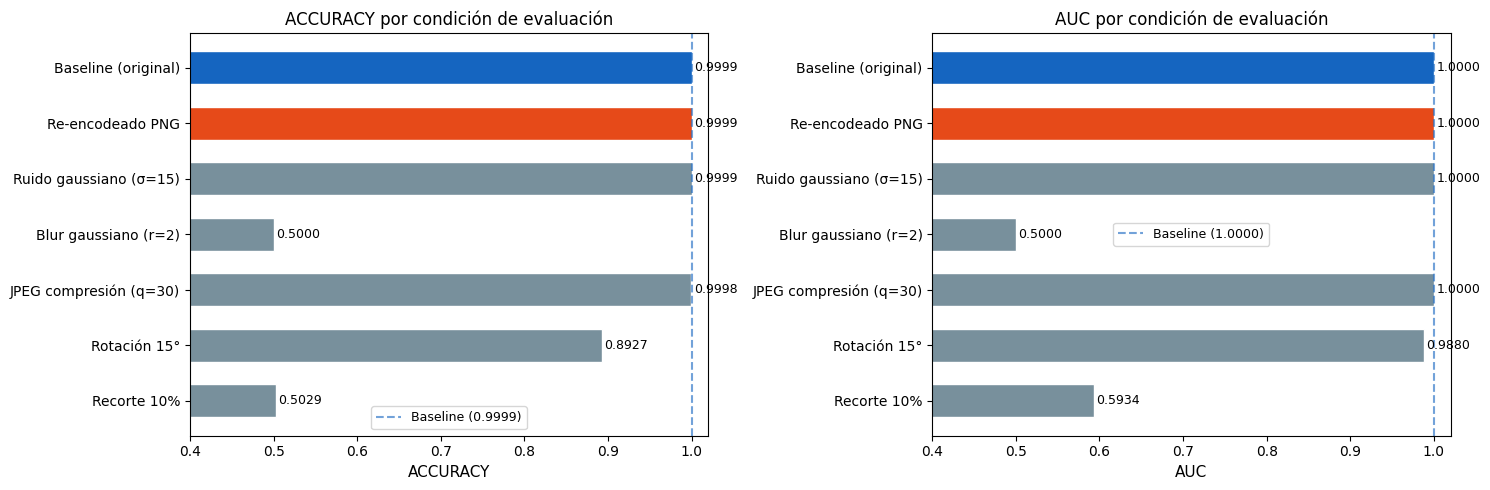

Gráfico guardado en outputs/robustness_comparison.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Colores: azul=baseline, naranja=re-encodeo, gris=degradaciones
colors = []
for r in results:
    if r["name"] == "Baseline (original)":
        colors.append("#1565C0")
    elif r["name"] == "Re-encodeado PNG":
        colors.append("#E64A19")
    else:
        colors.append("#78909C")

for ax, metric in zip(axes, ["accuracy", "auc"]):
    vals   = [r[metric] for r in results]
    names  = [r["name"] for r in results]
    bars   = ax.barh(names, vals, color=colors, edgecolor="white", height=0.6)
    ax.set_xlim(0.4, 1.02)
    ax.set_xlabel(metric.upper(), fontsize=11)
    ax.set_title(f"{metric.upper()} por condición de evaluación", fontsize=12)
    ax.axvline(x=results[0][metric], color="#1565C0", linestyle="--",
               alpha=0.6, label=f"Baseline ({results[0][metric]:.4f})")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.legend(fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUT_DIR / "robustness_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en outputs/robustness_comparison.png")

## 7. Deltas respecto al baseline

In [27]:
baseline_acc = results[0]["accuracy"]
baseline_auc = results[0]["auc"]

print(f"{'Condición':<35} {'ΔACC':>9} {'ΔAUC':>9}  Interpretación")
print("" * 80)
for r in results[1:]:
    delta_acc = r["accuracy"] - baseline_acc
    delta_auc = r["auc"]      - baseline_auc
    if abs(delta_acc) < 0.01:
        interp = "Sin impacto"
    elif abs(delta_acc) < 0.05:
        interp = "Impacto leve"
    elif abs(delta_acc) < 0.15:
        interp = "Impacto moderado"
    else:
        interp = "Impacto GRANDE ← señal de alerta"
    print(f"{r['name']:<35} {delta_acc:>+9.4f} {delta_auc:>+9.4f}  {interp}")

Condición                                ΔACC      ΔAUC  Interpretación

Re-encodeado PNG                      +0.0000   +0.0000  Sin impacto
Ruido gaussiano (σ=15)                +0.0000   -0.0000  Sin impacto
Blur gaussiano (r=2)                  -0.4999   -0.5000  Impacto GRANDE ← señal de alerta
JPEG compresión (q=30)                -0.0001   -0.0000  Sin impacto
Rotación 15°                          -0.1072   -0.0120  Impacto moderado
Recorte 10%                           -0.4970   -0.4066  Impacto GRANDE ← señal de alerta


## 8. Interpretación de resultados

### Re-encodeado PNG
| Resultado | Interpretación |
|-----------|----------------|
| Accuracy ≈ baseline | Los metadatos PNG **no** explican el resultado. El modelo aprendió algo de los píxeles. |
| Accuracy cae >5% | El modelo dependía parcialmente del fingerprint del generador. |
| Accuracy cae >15% | El modelo dependía principalmente del generador, no de los patrones visuales. |

### Degradaciones visuales
| Caída de accuracy | Interpretación |
|-------------------|----------------|
| < 3% | Modelo robusto, generaliza bien a variaciones reales. |
| 3–10% | Robustez moderada, aceptable para imágenes controladas. |
| > 10% | Fragilidad ante variaciones; no generalizaría a QRs reales escaneados. |

### Implicancia para el paper
Este experimento va más allá de lo reportado en la literatura revisada:
Trad y Chehab (2025), Alsulami et al. (2025) y los demás papers **no evalúan
robustez ante degradaciones ni dependencia del generador**.
Independientemente del resultado numérico, reportar este análisis es una
contribución metodológica que responde directamente a la brecha identificada
en la sección IV (*"Robustez ante condiciones reales"*).

In [28]:
# Guardar resultados para el paper
results_df.to_csv(OUT_DIR / "robustness_results.csv", index=False)
print(f"Resultados guardados en {OUT_DIR / 'robustness_results.csv'}")

Resultados guardados en outputs/robustness_results.csv
